In [1]:
# ==========================================
# KNN (TỰ XÂY THƯ VIỆN)
# ==========================================

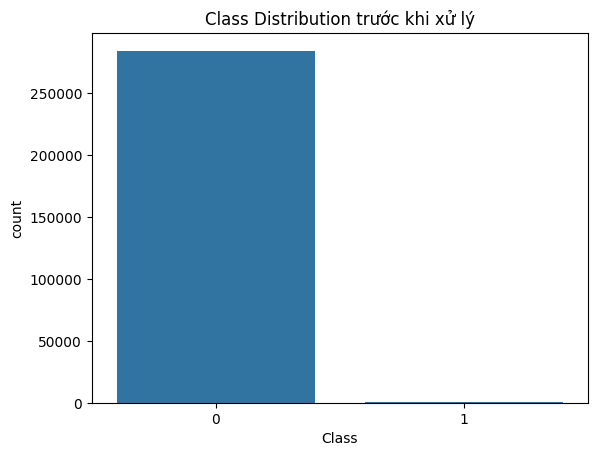

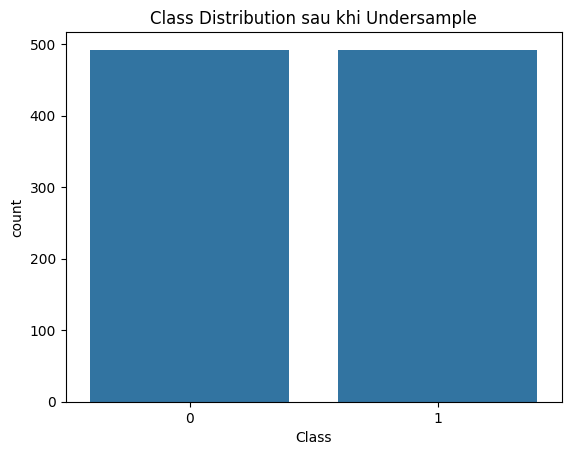

Tìm K tối ưu...
20/197 done
40/197 done
60/197 done
80/197 done
100/197 done
120/197 done
140/197 done
160/197 done
180/197 done
K=3: recall fraud = 0.869
20/197 done
40/197 done
60/197 done
80/197 done
100/197 done
120/197 done
140/197 done
160/197 done
180/197 done
K=5: recall fraud = 0.838
20/197 done
40/197 done
60/197 done
80/197 done
100/197 done
120/197 done
140/197 done
160/197 done
180/197 done
K=7: recall fraud = 0.838
20/197 done
40/197 done
60/197 done
80/197 done
100/197 done
120/197 done
140/197 done
160/197 done
180/197 done
K=9: recall fraud = 0.838
20/197 done
40/197 done
60/197 done
80/197 done
100/197 done
120/197 done
140/197 done
160/197 done
180/197 done
K=11: recall fraud = 0.828
20/197 done
40/197 done
60/197 done
80/197 done
100/197 done
120/197 done
140/197 done
160/197 done
180/197 done
K=13: recall fraud = 0.818
20/197 done
40/197 done
60/197 done
80/197 done
100/197 done
120/197 done
140/197 done
160/197 done
180/197 done
K=15: recall fraud = 0.818


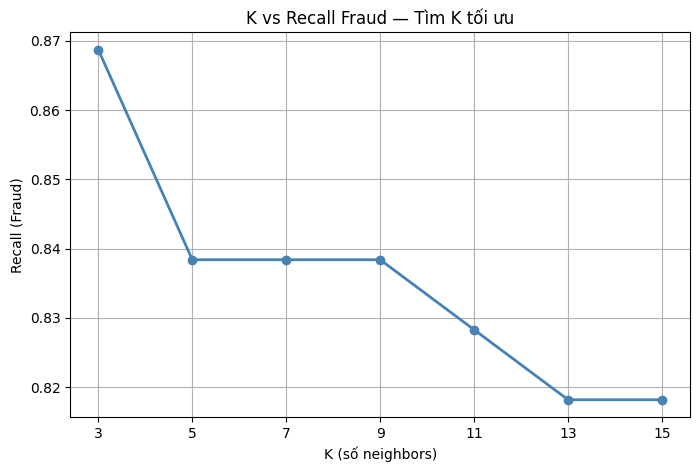


K tối ưu: 3 với recall = 0.869

=== TRAIN ===
20/787 done
40/787 done
60/787 done
80/787 done
100/787 done
120/787 done
140/787 done
160/787 done
180/787 done
200/787 done
220/787 done
240/787 done
260/787 done
280/787 done
300/787 done
320/787 done
340/787 done
360/787 done
380/787 done
400/787 done
420/787 done
440/787 done
460/787 done
480/787 done
500/787 done
520/787 done
540/787 done
560/787 done
580/787 done
600/787 done
620/787 done
640/787 done
660/787 done
680/787 done
700/787 done
720/787 done
740/787 done
760/787 done
780/787 done
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       394
           1       0.99      0.92      0.95       393

    accuracy                           0.95       787
   macro avg       0.96      0.95      0.95       787
weighted avg       0.96      0.95      0.95       787

ROC AUC Score:  0.9529423541416412

=== TEST ===
20/197 done
40/197 done
60/197 done
80/197 done
100/197 done
120/197 done


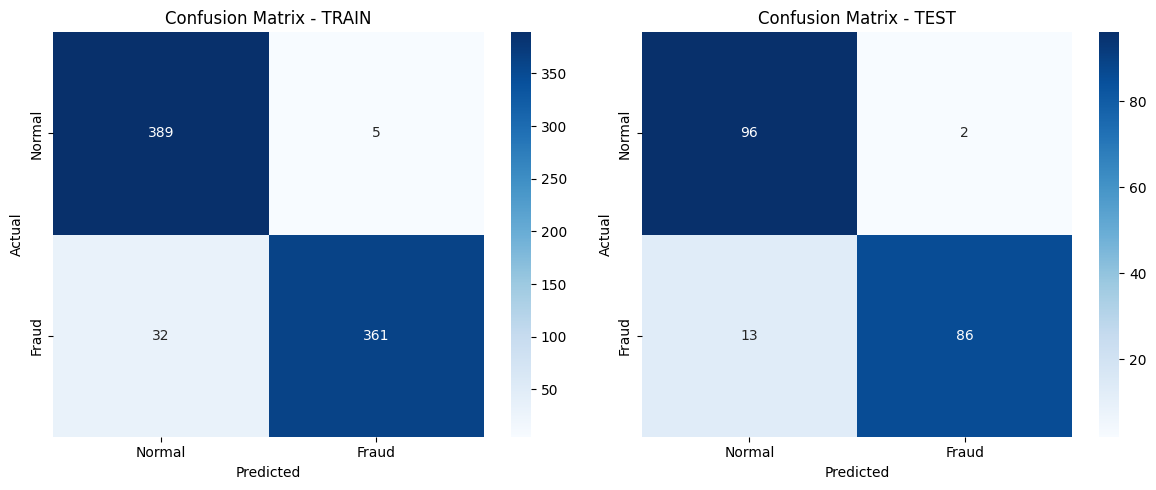

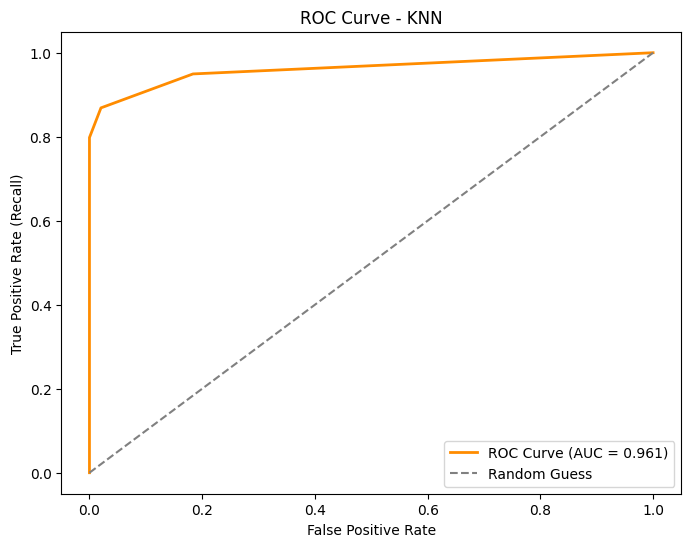

In [2]:
# ==========================================
# BƯỚC 1 — Import
# ==========================================
import pandas as pd
import numpy as np
import seaborn as sns
import sqlite3
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score as roc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# ==========================================
# BƯỚC 2 — Tự build KNN
# ==========================================

class KNN:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def _predict_one(self, x):
        distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.n_neighbors]
        k_labels = self.y_train[k_indices]
        return Counter(k_labels).most_common(1)[0][0]

    def predict(self, X):
        X = np.array(X)
        result = []
        for i, x in enumerate(X):
            result.append(self._predict_one(x))
            if (i + 1) % 20 == 0:
                print(f"{i+1}/{len(X)} done")
        return np.array(result)

    def predict_proba(self, X):
        # Trả về tỷ lệ K neighbors vote là fraud → dùng để vẽ ROC curve
        X = np.array(X)
        proba = []
        for x in X:
            distances = [self._euclidean_distance(x, x_train) for x_train in self.X_train]
            k_indices = np.argsort(distances)[:self.n_neighbors]
            k_labels = self.y_train[k_indices]
            fraud_ratio = np.sum(k_labels == 1) / self.n_neighbors
            proba.append(fraud_ratio)
        return np.array(proba)


# ==========================================
# BƯỚC 3 — Load data qua SQLite
# ==========================================
df_raw = pd.read_csv('./dataset/creditcard.csv')
conn = sqlite3.connect('credit_card.db')
df_raw.to_sql('transactions', conn, if_exists='replace', index=False)
dataset = pd.read_sql_query("SELECT * FROM transactions LIMIT 5", conn)
dataset.head()

# ==========================================
# BƯỚC 4 — Visualize imbalance
# ==========================================
all_data = pd.read_sql_query("SELECT Class FROM transactions", conn)
sns.countplot(x='Class', data=all_data)
plt.title('Class Distribution trước khi xử lý')
plt.show()

# ==========================================
# BƯỚC 5 — Tách fraud/normal qua SQL
# ==========================================
positiveDataset = pd.read_sql_query("SELECT * FROM transactions WHERE Class = 1", conn)
negativeDataset = pd.read_sql_query("SELECT * FROM transactions WHERE Class = 0", conn)
conn.close()

# ==========================================
# BƯỚC 6 — Undersampling
# ==========================================
negativeDataset_down = resample(
    negativeDataset,
    n_samples=len(positiveDataset),
    random_state=21
)
balancedDataset = pd.concat([positiveDataset, negativeDataset_down])

sns.countplot(x='Class', data=balancedDataset)
plt.title('Class Distribution sau khi Undersample')
plt.show()

# ==========================================
# BƯỚC 7 — Split train/test
# ==========================================
X = balancedDataset.drop(columns=['Class'])
y = balancedDataset['Class']

xTrain, xTest, yTrain, yTest = tts(
    X, y,
    test_size=0.2,
    random_state=21,
    stratify=y
)

# ==========================================
# BƯỚC 8 — Scale
# ==========================================
scaler = StandardScaler()
xTrain = scaler.fit_transform(xTrain)
xTest = scaler.transform(xTest)

# ==========================================
# BƯỚC 9 — Tìm K tối ưu (thay feature importance)
# ==========================================
from sklearn.metrics import recall_score

k_values = [3, 5, 7, 9, 11, 13, 15]
recall_scores = []

print("Tìm K tối ưu...")
for k in k_values:
    knn_temp = KNN(n_neighbors=k)
    knn_temp.fit(xTrain, yTrain)
    pred_temp = knn_temp.predict(xTest)
    recall = recall_score(yTest, pred_temp, pos_label=1)
    recall_scores.append(recall)
    print(f"K={k}: recall fraud = {recall:.3f}")

# Vẽ biểu đồ K vs Recall
plt.figure(figsize=(8, 5))
plt.plot(k_values, recall_scores, marker='o', color='steelblue', linewidth=2)
plt.xticks(k_values)
plt.xlabel('K (số neighbors)')
plt.ylabel('Recall (Fraud)')
plt.title('K vs Recall Fraud — Tìm K tối ưu')
plt.grid(True)
plt.show()

# Chọn K tốt nhất
best_k = k_values[np.argmax(recall_scores)]
print(f"\nK tối ưu: {best_k} với recall = {max(recall_scores):.3f}")

# ==========================================
# BƯỚC 10 — Train với K tối ưu
# ==========================================
classifier = KNN(n_neighbors=best_k)
classifier.fit(xTrain, yTrain)

# ==========================================
# BƯỚC 11 — Evaluate
# ==========================================
print("\n=== TRAIN ===")
predTrain = classifier.predict(xTrain)
print(classification_report(yTrain, predTrain))
print('ROC AUC Score: ', roc(yTrain, predTrain))

print("\n=== TEST ===")
predTest = classifier.predict(xTest)
print(classification_report(yTest, predTest))
print('ROC AUC Score: ', roc(yTest, predTest))

# ==========================================
# BƯỚC 12 — Confusion Matrix
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_train = confusion_matrix(yTrain, predTrain)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
axes[0].set_title('Confusion Matrix - TRAIN')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_test = confusion_matrix(yTest, predTest)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])
axes[1].set_title('Confusion Matrix - TEST')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ==========================================
# BƯỚC 13 — ROC Curve
# ==========================================
proba_test = classifier.predict_proba(xTest)
fpr, tpr, _ = roc_curve(yTest, proba_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - KNN')
plt.legend()
plt.show()

20/20 done
n=50: 0.0069s
20/20 done
n=100: 0.0150s
20/20 done
n=150: 0.0191s
20/20 done
n=200: 0.0244s
20/20 done
n=250: 0.0294s
20/20 done
n=300: 0.0299s
20/20 done
n=350: 0.0356s


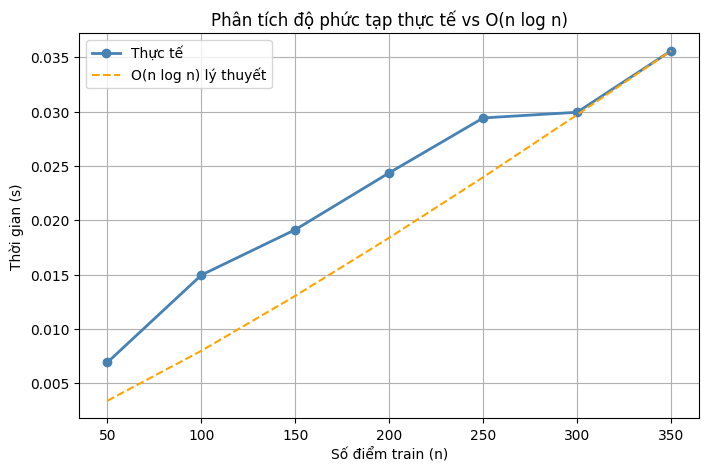

In [3]:
import time
import matplotlib.pyplot as plt
import numpy as np

# Lấy subset với kích thước tăng dần
sample_sizes = [50, 100, 150, 200, 250, 300, 350]
times = []

for n in sample_sizes:
    X_sub = xTrain[:n]
    y_sub = yTrain[:n]
    
    knn_temp = KNN(n_neighbors=best_k)
    knn_temp.fit(X_sub, y_sub)
    
    start = time.time()
    knn_temp.predict(xTest[:20])  # fix test size để chỉ đo ảnh hưởng của n train
    end = time.time()
    
    times.append(end - start)
    print(f"n={n}: {end-start:.4f}s")

# Vẽ
plt.figure(figsize=(8, 5))
plt.plot(sample_sizes, times, marker='o', color='steelblue', linewidth=2, label='Thực tế')

# Vẽ đường O(n log n) để so sánh
n_arr = np.array(sample_sizes)
theoretical = n_arr * np.log(n_arr)
theoretical = theoretical / theoretical.max() * max(times)  # scale cho khớp
plt.plot(sample_sizes, theoretical, linestyle='--', color='orange', label='O(n log n) lý thuyết')

plt.xlabel('Số điểm train (n)')
plt.ylabel('Thời gian (s)')
plt.title('Phân tích độ phức tạp thực tế vs O(n log n)')
plt.legend()
plt.grid(True)
plt.show()

Đang vẽ decision boundary, chờ tí...
20/44336 done
40/44336 done
60/44336 done
80/44336 done
100/44336 done
120/44336 done
140/44336 done
160/44336 done
180/44336 done
200/44336 done
220/44336 done
240/44336 done
260/44336 done
280/44336 done
300/44336 done
320/44336 done
340/44336 done
360/44336 done
380/44336 done
400/44336 done
420/44336 done
440/44336 done
460/44336 done
480/44336 done
500/44336 done
520/44336 done
540/44336 done
560/44336 done
580/44336 done
600/44336 done
620/44336 done
640/44336 done
660/44336 done
680/44336 done
700/44336 done
720/44336 done
740/44336 done
760/44336 done
780/44336 done
800/44336 done
820/44336 done
840/44336 done
860/44336 done
880/44336 done
900/44336 done
920/44336 done
940/44336 done
960/44336 done
980/44336 done
1000/44336 done
1020/44336 done
1040/44336 done
1060/44336 done
1080/44336 done
1100/44336 done
1120/44336 done
1140/44336 done
1160/44336 done
1180/44336 done
1200/44336 done
1220/44336 done
1240/44336 done
1260/44336 done
1280/443

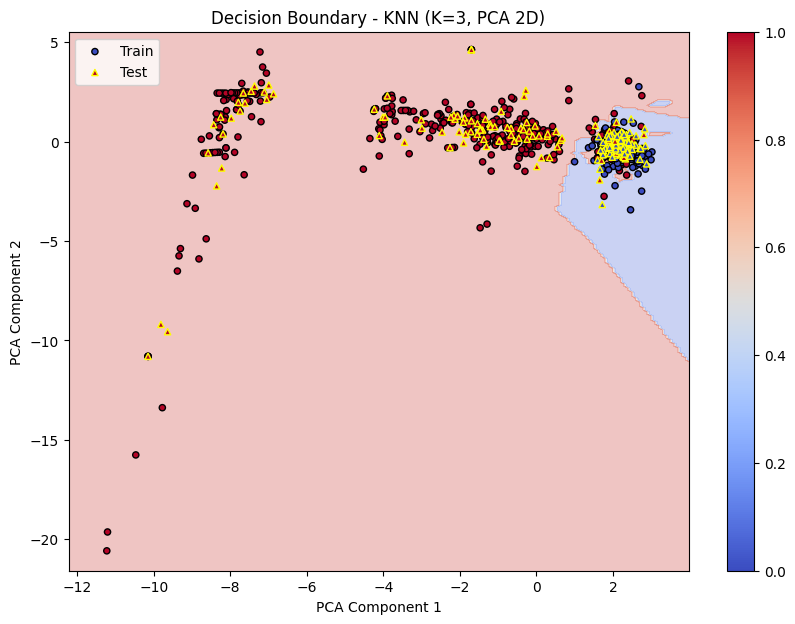

In [4]:
from sklearn.decomposition import PCA

# Giảm chiều xuống 2D bằng PCA
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(xTrain)
X_test_2d = pca.transform(xTest)

# Train KNN trên 2D
knn_2d = KNN(n_neighbors=best_k)
knn_2d.fit(X_train_2d, yTrain)

# Tạo meshgrid
x_min, x_max = X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1
y_min, y_max = X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict toàn bộ meshgrid
print("Đang vẽ decision boundary, chờ tí...")
mesh_points = np.c_[xx.ravel(), yy.ravel()]
Z = knn_2d.predict(mesh_points)
Z = Z.reshape(xx.shape)

# Vẽ
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], 
            c=yTrain, cmap='coolwarm', edgecolors='k', s=20, label='Train')
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], 
            c=yTest, cmap='coolwarm', edgecolors='yellow', s=20, marker='^', label='Test')
plt.title(f'Decision Boundary - KNN (K={best_k}, PCA 2D)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.colorbar()
plt.show()

Cần 17 PC để giữ 95% thông tin
Cần 23 PC để giữ 99% thông tin
Elbow point: PC17 (gain < 1% từ đây)


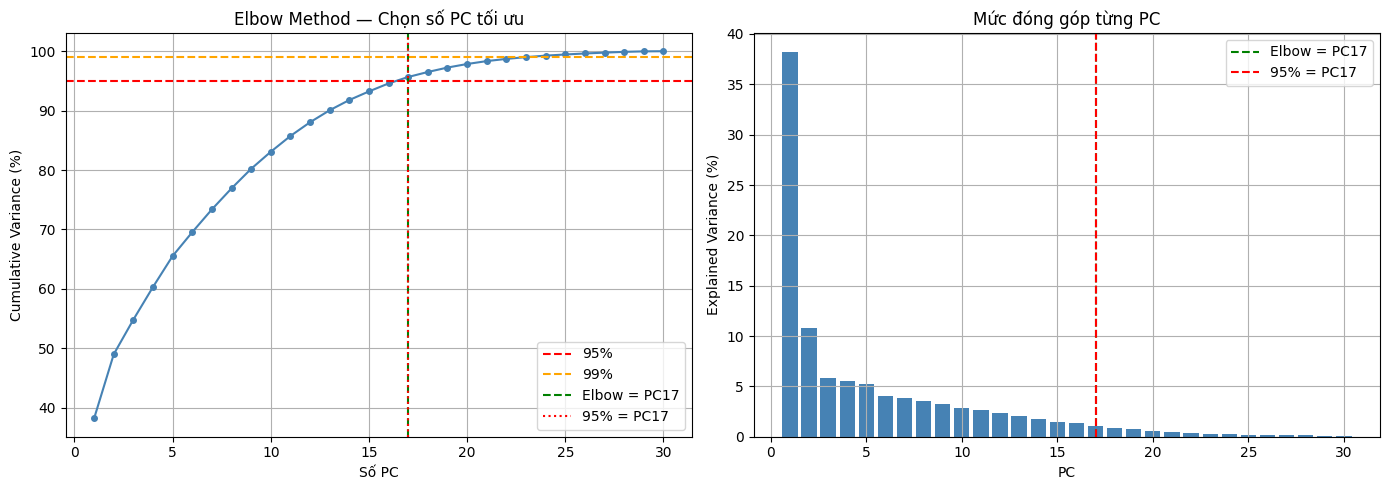


So sánh Recall fraud với số PC khác nhau (KNN):
--------------------------------------------------
20/197 done
40/197 done
60/197 done
80/197 done
100/197 done
120/197 done
140/197 done
160/197 done
180/197 done
PC=17 (95.7% variance) → Recall fraud = 0.848
20/197 done
40/197 done
60/197 done
80/197 done
100/197 done
120/197 done
140/197 done
160/197 done
180/197 done
PC=17 (95.7% variance) → Recall fraud = 0.848
20/197 done
40/197 done
60/197 done
80/197 done
100/197 done
120/197 done
140/197 done
160/197 done
180/197 done
PC=23 (99.0% variance) → Recall fraud = 0.859
20/197 done
40/197 done
60/197 done
80/197 done
100/197 done
120/197 done
140/197 done
160/197 done
180/197 done
PC=30 (100.0% variance) → Recall fraud = 0.869


In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# BƯỚC 1 — Fit PCA trên toàn bộ 30 chiều
# ==========================================
pca = PCA()
pca.fit(xTrain)

cumsum = np.cumsum(pca.explained_variance_ratio_)
explained = pca.explained_variance_ratio_

# ==========================================
# BƯỚC 2 — Tìm số PC tối ưu
# ==========================================
n_95 = np.argmax(cumsum >= 0.95) + 1
n_99 = np.argmax(cumsum >= 0.99) + 1

print(f"Cần {n_95} PC để giữ 95% thông tin")
print(f"Cần {n_99} PC để giữ 99% thông tin")

gains = np.diff(cumsum)
elbow = np.argmax(gains < 0.01) + 1
print(f"Elbow point: PC{elbow} (gain < 1% từ đây)")

# ==========================================
# BƯỚC 3 — Vẽ đồ thị
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(cumsum)+1), cumsum*100,
             marker='o', markersize=4, color='steelblue')
axes[0].axhline(y=95, color='red', linestyle='--', label='95%')
axes[0].axhline(y=99, color='orange', linestyle='--', label='99%')
axes[0].axvline(x=elbow, color='green', linestyle='--',
                label=f'Elbow = PC{elbow}')
axes[0].axvline(x=n_95, color='red', linestyle=':',
                label=f'95% = PC{n_95}')
axes[0].set_xlabel('Số PC')
axes[0].set_ylabel('Cumulative Variance (%)')
axes[0].set_title('Elbow Method — Chọn số PC tối ưu')
axes[0].legend()
axes[0].grid(True)

axes[1].bar(range(1, len(explained)+1), explained*100, color='steelblue')
axes[1].axvline(x=elbow, color='green', linestyle='--',
                label=f'Elbow = PC{elbow}')
axes[1].axvline(x=n_95, color='red', linestyle='--',
                label=f'95% = PC{n_95}')
axes[1].set_xlabel('PC')
axes[1].set_ylabel('Explained Variance (%)')
axes[1].set_title('Mức đóng góp từng PC')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# BƯỚC 4 — So sánh KNN với các số PC khác nhau
# ==========================================
from sklearn.metrics import recall_score

print("\nSo sánh Recall fraud với số PC khác nhau (KNN):")
print("-" * 50)

test_components = [elbow, n_95, n_99, 30]

for n in test_components:
    pca_temp = PCA(n_components=n)
    X_train_pca = pca_temp.fit_transform(xTrain)
    X_test_pca = pca_temp.transform(xTest)

    # Dùng KNN thay RF
    knn_temp = KNN(n_neighbors=best_k)  # dùng K tối ưu đã tìm trước đó
    knn_temp.fit(X_train_pca, yTrain)

    pred_temp = knn_temp.predict(X_test_pca)
    recall = recall_score(yTest, pred_temp, pos_label=1)
    var = cumsum[n-1] * 100

    print(f"PC={n:2d} ({var:.1f}% variance) → Recall fraud = {recall:.3f}")